In [19]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import seaborn as sns
sns.set(style='ticks')

import matplotlib.gridspec as gridspec
import ast
import sys
sys.path.append('../no_degeneracy/')
sys.path.append('../no_degeneracy/Prior/')
from mcmc import *
from parallel import *
from fit_prior import read_prior_par
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error



colors_figures = {
'4e-3x': ['#fee0d2', '#deebf7'],
'2x':    ['#fc9272', '#9ecae1'],
'1x':    ['#de2d26', '#3182bd'],
'ann' : '#de2d26', 
'bms' : '#3182bd',
'data': sns.color_palette("colorblind")[7],
'noise': sns.color_palette("colorblind")[7]
}

#Text sizes  
#--------------------------------
size_axis=16;size_ticks=14;
size_title=16;
line_w=3;marker_s=8;m_size=10
size_legend=6
#--------------------------------

#Errors nn 
#--------------------------------------------------------------------------
def compute_errors_ann(df_function):
    
    #Validation and train borders
    n_points=int(len(df_function.index))
    
    train_fraction=5/8;valid_fraction=1/8;test_fraction=0.2
    train_size_ann=int(n_points*train_fraction)
    train_size_bms=train_size_ann + int(n_points*valid_fraction)
    train_border=df_function.loc[train_size_bms-1]['x1']

    #compute errors
    #ann errors
    rmse_nn_tr=root_mean_squared_error(df_function.loc[:train_size_bms-1]['ymodel'],df_function.loc[:train_size_bms -1]['y'])
    rmse_nn_tt=root_mean_squared_error(df_function.loc[train_size_bms-1:]['ymodel'],df_function.loc[train_size_bms -1:]['y'])


    return rmse_nn_tr, rmse_nn_tt, train_border
#--------------------------------------------------------------------------

#Errors bms 
#--------------------------------------------------------------------------
def compute_errors_bms(df_function):
    
    #Validation and train borders
    n_points=int(len(df_function.index))
    
    train_fraction=5/8;valid_fraction=1/8;test_fraction=0.2
    train_size_ann=int(n_points*train_fraction)
    train_size_bms=train_size_ann + int(n_points*valid_fraction)
    train_border=df_function.loc[train_size_bms-1]['x1']

    #bms errors
    try:
        rmse_mdl_tr=root_mean_squared_error(dplot.loc[:train_size_bms-1]['ybms'],dplot.loc[:train_size_bms-1]['y'])
    except ValueError:
        rmse_mdl_tr=np.inf
    try:
        rmse_mdl_tt =root_mean_squared_error(dplot.loc[train_size_bms-1:]['ybms'],dplot.loc[train_size_bms-1:]['y'])
    except ValueError:
        rmse_mdl_tet=np.inf


    return rmse_mdl_tr, rmse_mdl_tt
#--------------------------------------------------------------------------


In [24]:
#ANN architecture                                                                                   
#--------------------------------------------------                                                 
ILS, NL, LS, OLS = 1, 7,12,1

architecture=[ILS] + NL*[LS] + [OLS]
net_architecture='ILS%s_NL%s_LS%s' % (ILS, NL, LS)
#--------------------------------------------------

#Read NN and BMS data
step=0.1 #0.1, 0.05, 0.025, 0.004
function='tanh' #tanh, leaky_ReLU
n=0;sigma=0.0;realization=0

path_nn='../../data/alternative_experiments/%s/nns/%s/approximations/' % (net_architecture, str(step)) 
model_nn='NN_no_overfit_%s_sigma_%s_r_%s.csv' % (function, str(sigma), str(realization) )
data=path_nn+model_nn

data=pd.read_csv(data,index_col=0)

dn=data[data['rep']==n]
dn=dn.reset_index(drop=True)
display(dn)

,x1,y,rep,noise,y_noise,ymodel
0,-2.000000e+00,0.101673,0.0,0.0,0.101673,0.116537
1,-1.900000e+00,0.108131,0.0,0.0,0.108131,0.115598
2,-1.800000e+00,0.113935,0.0,0.0,0.113935,0.114557
3,-1.700000e+00,0.118791,0.0,0.0,0.118791,0.113456
4,-1.600000e+00,0.122400,0.0,0.0,0.122400,0.112389
5,-1.500000e+00,0.124506,0.0,0.0,0.124506,0.111555
6,-1.400000e+00,0.125013,0.0,0.0,0.125013,0.111347
7,-1.300000e+00,0.124222,0.0,0.0,0.124222,0.112512
8,-1.200000e+00,0.123306,0.0,0.0,0.123306,0.116431
9,-1.100000e+00,0.125154,0.0,0.0,0.125154,0.125578


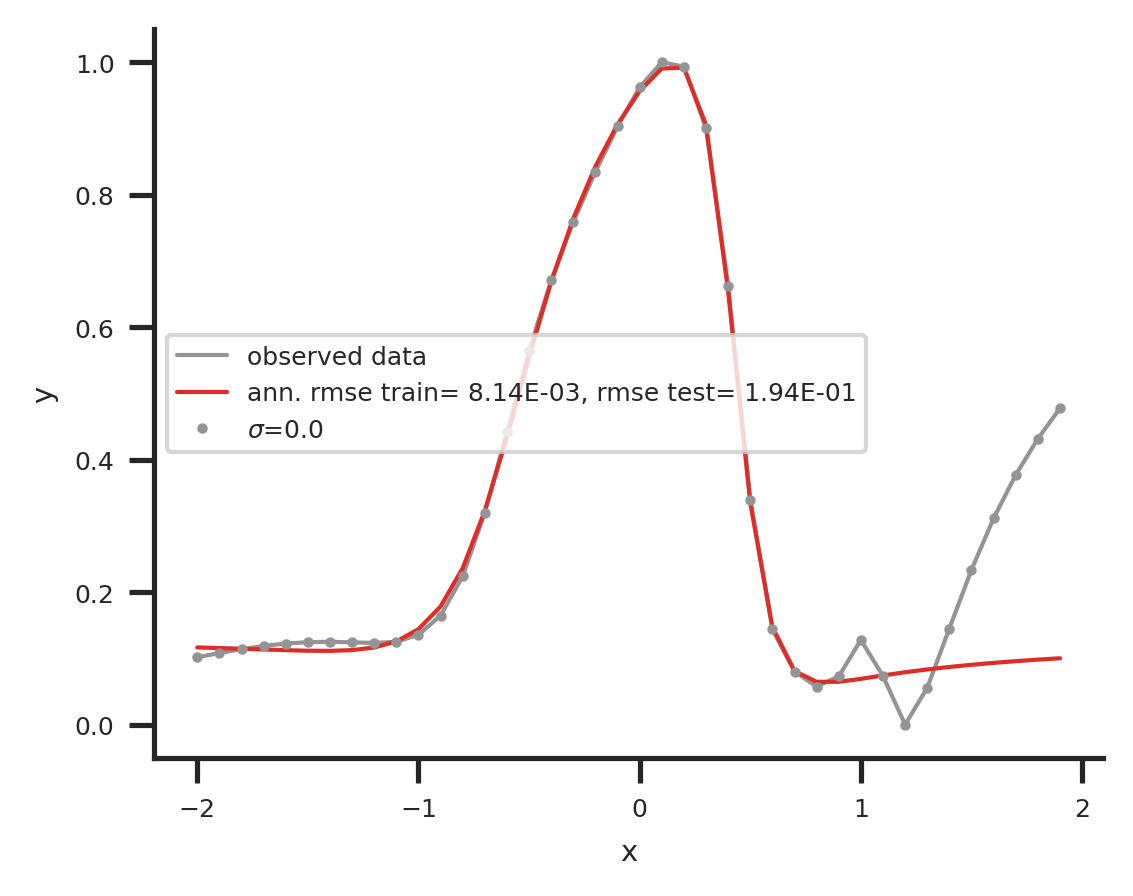

In [25]:
#Plot

#ann errors
rmse_nn_train, rmse_nn_test, train_border = compute_errors_ann(dn)

#Define figure size in cm                                                                           
cm = 1/2.54 #convert inch to cm                                                                     
width = 10*cm; height=8*cm

Extensions=['.png']

#Fonts and sizes                                                                                    
size_axis=7;size_ticks=6;size_title=5
line_w=1;marker_s=3 #width and marker size                                                          


fig=figure(figsize=(width,height), dpi=300)

plt.plot(dn['x1'], dn['y'],linewidth=line_w, markersize=2, color=colors_figures['data'],label='observed data')     
plt.plot(dn['x1'], dn['ymodel'],linewidth=line_w, color=colors_figures['ann'], label=\
         'ann. rmse train= %.2E, rmse test= %.2E' % ( rmse_nn_train, rmse_nn_test))

#0.01, 0.23, r"$a = {0:s}$".format(as_si(a,2))

plt.plot(dn['x1'], dn['y_noise'],'.',markersize=marker_s, linewidth=line_w, color=colors_figures['noise'],label=r'$\sigma$=' + str(sigma) )

plt.xlabel('x',fontsize=size_axis);plt.ylabel('y',fontsize=size_axis)
plt.xticks(fontsize=size_ticks);plt.yticks(fontsize=size_ticks)


plt.legend(loc='best', fontsize=size_legend)
#set limits and layout
sns.despine();plt.tight_layout()

In [28]:
#Read BMS trace
NREP=50000
NPAR=10
path_bms='../../data/alternative_experiments/%s/MStraces/%s/' % (net_architecture, str(step)) 

#filename='BMS_'+function+'_n_'+str(n)+'_sigma_'+str(sigma)+ '_r_' + str(realization) + '_res_' + resolutions[resolution] + '_trace_'+\
#                str(steps)+'_prior_'+str(NPAR)+ '.csv'

filename='BMS_%s_%s_n_%s_sigma_%s_r_%s_trace_%s_prior_%s.csv' % \
(function, net_architecture, str(n), str(sigma), str(realization), str(NREP), str(NPAR)) 

trace=pd.read_csv(path_bms + filename, sep=';', header=None, names=['t', 'H', 'expr', 'parvals', 'kk1', 'kk2','kk3'])


#Parameters to read models
VARS = ['x1',]
x = dn[[c for c in VARS]].copy()


if NPAR==10:
    prior_par = read_prior_par('../no_degeneracy/Prior/final_prior_param_sq.named_equations.nv1.np10.2017-10-18 18:07:35.089658.dat')
elif NPAR==20:
    prior_par = read_prior_par('../no_degeneracy/Prior/final_prior_param_sq.named_equations.nv1.np20.maxs200.2024-05-10 162907.551306.dat')

In [33]:
#Minimum description length model
#y=dn.y_noise
y=dn.y


minrow = trace[trace.H == min(trace.H)].iloc[0]
display(minrow)
minH, minexpr, minparvals = minrow.H, minrow.expr, ast.literal_eval(minrow.parvals)

t = Tree(
    variables=list(x.columns),
    parameters=['a%d' % i for i in range(NPAR)],
    x=x, y=y,
    prior_par=prior_par,
    max_size=200,
    from_string=minexpr,
)

t.set_par_values(deepcopy(minparvals))

t                                                       3925
H                                                 -15.292775
expr         pow2(cos(((_a3_ * (x1 * (x1 + _a5_))) + _a5_)))
parvals    {'d0': {'_a3_': np.float64(0.5248532431208967)...
kk1                  {'d0': np.float64(0.05650946811537242)}
kk2                                                -92.89643
kk3                                                 31.15544
Name: 3925, dtype: object

ValueError: malformed node or string on line 1: <ast.Call object at 0x76a190537340>

In [ ]:
Nini = 00
plt.figure(figsize=(15, 5))




#Define figure size in cm                                                                           
Extensions=['.svg']

#Fonts and sizes                                                                                    
size_axis=7;size_ticks=6;size_title=5
line_w=1;marker_s=3 #width and marker size                                                           
#plt.title(str(function) + ', ' + 'n=' + str(n) +', r=' + str(realization))
plt.plot(trace.t[trace.t > Nini], trace.H[trace.t > Nini], color=color_bms)
plt.xticks(fontsize=20);plt.yticks(fontsize=20)
plt.xlabel('steps',fontsize=24);plt.ylabel('Energy',fontsize=24)
#plt.scatter(minrow['t'], minH,color='r')
sns.despine(trim=True)

Name_figure='Energy_' + function + '_n_' + str(n) + '_sigma_' + str(sigma) + '_r_'  + str(realization) + '_par_' + str(NPAR)

for ext in Extensions:
        plt.savefig('../../results/' + Name_figure + ext,dpi=300)

 
plt.show()

In [ ]:
#Plot

#Validation and train borders
n_points=int(len(dn.index))
print(n_points)
train_fraction=5/8;valid_fraction=1/8;test_fraction=0.2
train_size_ann=int(n_points*train_fraction)
train_size_bms=train_size_ann + int(n_points*valid_fraction)


train_border=dn.loc[train_size_bms-1]['x1']
print(train_border)

dplot = deepcopy(dn)
dplot['ybms'] = t.predict(x)
display(dplot.loc[train_size_ann-1:])

#ann errors
rmse_nn_train=root_mean_squared_error(dplot.loc[:train_size_bms-1]['ymodel'],dplot.loc[:train_size_bms -1]['y'])
rmse_nn_test=root_mean_squared_error(dplot.loc[train_size_bms-1:]['ymodel'],dplot.loc[train_size_bms -1:]['y'])
#rmse_nn_validation=root_mean_squared_error(dplot.iloc[validation_points]['ymodel'],dplot.iloc[validation_points]['y'])

#bms errors
rmse_mdl=root_mean_squared_error(dplot.ybms,dn.y)
rmse_mdl_train=root_mean_squared_error(dplot.loc[:train_size_bms-1]['ybms'],dn.loc[:train_size_bms-1]['y'])
rmse_mdl_test =root_mean_squared_error(dplot.loc[train_size_bms-1:]['ybms'],dn.loc[train_size_bms-1:]['y'])

 
#Define figure size in cm                                                                           
cm = 1/2.54 #convert inch to cm                                                                     
width = 10*cm; height=8*cm

Extensions=['.png']

#Fonts and sizes                                                                                    
size_axis=7;size_ticks=6;size_title=5
line_w=1;marker_s=3 #width and marker size                                                          


fig=figure(figsize=(width,height), dpi=300)           


 
                                                                            
#plt.plot(dn['x1'], dn['y_noise'],linewidth=line_w, markersize=2, color=color_noise,label=r'$\sigma$=' + str(sigma) )
plt.plot(dn['x1'], dn['y'],'.', markersize=2, color=color_data,label='observed data')     
plt.plot(dn['x1'], dn['ymodel'],linewidth=line_w, color=color_ann, label='ann.  rmse_train= %.2E, rmse_test= %.2E' % ( rmse_nn_train, rmse_nn_test))
plt.plot(dplot.x1, dplot.ybms, color=color_bms, linestyle='--',label='mdl.  rmse_train= %.2E, rmse_test= %.2E' % ( rmse_mdl_train, rmse_mdl_test))
plt.axvline(x=2,linestyle='--',linewidth=line_w, color='k')

#plt.axvline(x=train_border,linestyle='--',linewidth=line_w, color='k')

#plt.title('$%s$' % t.latex(),fontsize=size_title)
plt.title('$%s$, $\Delta x$=%s, n=%d, r=%d' % ( t.latex(),resolutions[resolution], n, realization),fontsize=size_title)
plt.xlabel('x',fontsize=size_axis);plt.ylabel('y',fontsize=size_axis)
plt.xticks(fontsize=size_ticks);plt.yticks(fontsize=size_ticks)
plt.legend(loc='best', fontsize=size_ticks)

plt.xlim(-2,xlim[1]);plt.ylim(-0.15,1.1)  


Name_figure='Prediction_' + resolution + '_' + function + '_n_' + str(n) + '_sigma_' + str(sigma) + '_r_'  + str(realization) + '_par_' + str(NPAR)

    
for ext in Extensions:
        plt.savefig('../../results/' + Name_figure +ext,dpi=300)

plt.show()